In [2]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# reading excel file
df=pd.read_excel("/content/covid19_entries.xlsx")

In [4]:
# first five entries
df.head()

,Date,Cases
0,2020-01-01,285
1,2020-01-02,4030
2,2020-01-03,955
3,2020-01-04,2813
4,2020-01-05,2945


In [5]:
# last five entries
df.tail()

,Date,Cases
195,2020-07-14,1161
196,2020-07-15,2514
197,2020-07-16,1884
198,2020-07-17,4860
199,2020-07-18,4852


<Axes: >

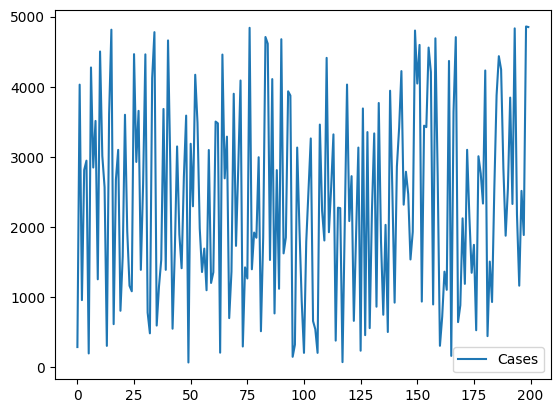

In [6]:
# plotting the graphs
df.plot()

In [7]:
# changing the column names of the DataFrame
df.columns = ['ds','y']
df.head()

,ds,y
0,2020-01-01,285
1,2020-01-02,4030
2,2020-01-03,955
3,2020-01-04,2813
4,2020-01-05,2945


In [8]:
# dropping row
df.drop(144,axis=0,inplace=True)

In [9]:
#last five entries
df.tail()

,ds,y
195,2020-07-14,1161
196,2020-07-15,2514
197,2020-07-16,1884
198,2020-07-17,4860
199,2020-07-18,4852


In [10]:
# Converting Date Column to DateTime Format
df['ds'] = pd.to_datetime(df['ds'])

In [11]:
# last five entries
df.head()

,ds,y
0,2020-01-01,285
1,2020-01-02,4030
2,2020-01-03,955
3,2020-01-04,2813
4,2020-01-05,2945


In [12]:
# first five entries
df.tail()

,ds,y
195,2020-07-14,1161
196,2020-07-15,2514
197,2020-07-16,1884
198,2020-07-17,4860
199,2020-07-18,4852


In [13]:
# Displaying Prophet Methods and Functions
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [14]:
# Initialize the Model
model=Prophet()

In [15]:
# displaying columns names
df.columns

Index(['ds', 'y'], dtype='object')

In [16]:
# Removing Missing Values from Dataset
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,2020-01-01,285
1,2020-01-02,4030
2,2020-01-03,955
3,2020-01-04,2813
4,2020-01-05,2945


In [18]:
# trains the Prophet model using the dataset df
model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [19]:
# Displaying Prophet Component Modes
model.component_modes

{'additive': ['weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [20]:
# last five entries
df.tail()

,ds,y
195,2020-07-14,1161
196,2020-07-15,2514
197,2020-07-16,1884
198,2020-07-17,4860
199,2020-07-18,4852


In [21]:
# Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [22]:
# Displaying Last Rows of Future Dates
future_dates.tail()

,ds
559,2021-07-14
560,2021-07-15
561,2021-07-16
562,2021-07-17
563,2021-07-18


In [23]:
# Generating COVID-19 Forecast Predictions
prediction=model.predict(future_dates)

In [24]:
# Displaying Predicted COVID-19 Forecast Values
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,2199.441843,4.913386,3368.266476,2199.441843,2199.441843,-451.307698,-451.307698,-451.307698,-451.307698,-451.307698,-451.307698,0.0,0.0,0.0,1748.134145
1,2020-01-02,2201.005809,209.129044,3736.315766,2201.005809,2201.005809,-203.717299,-203.717299,-203.717299,-203.717299,-203.717299,-203.717299,0.0,0.0,0.0,1997.288510
2,2020-01-03,2202.569776,668.959502,4288.132351,2202.569776,2202.569776,245.982155,245.982155,245.982155,245.982155,245.982155,245.982155,0.0,0.0,0.0,2448.551930
3,2020-01-04,2204.133742,759.678269,4065.208578,2204.133742,2204.133742,111.181927,111.181927,111.181927,111.181927,111.181927,111.181927,0.0,0.0,0.0,2315.315669
4,2020-01-05,2205.697709,445.019992,3874.315313,2205.697709,2205.697709,-47.249467,-47.249467,-47.249467,-47.249467,-47.249467,-47.249467,0.0,0.0,0.0,2158.448241


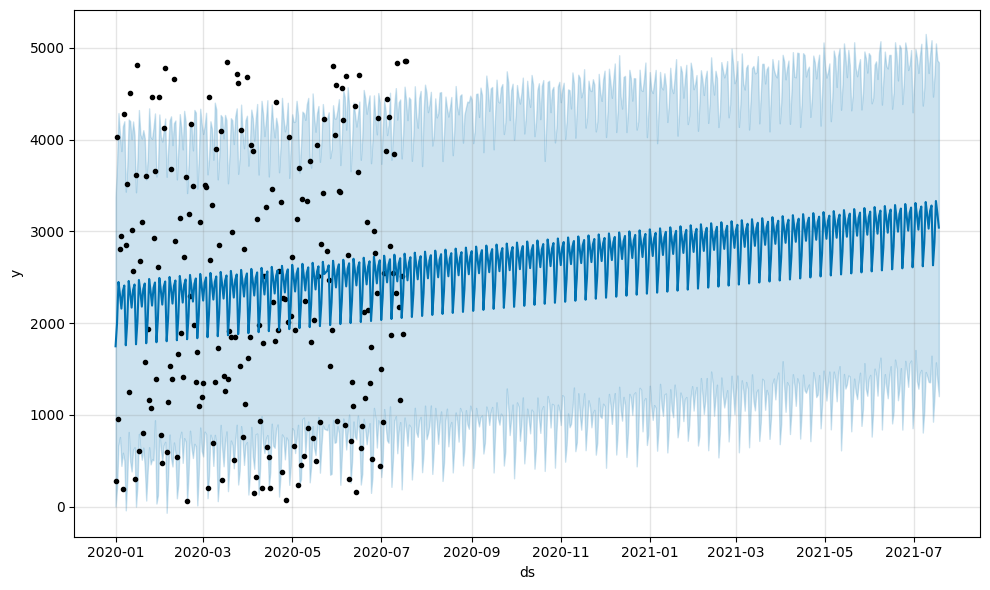

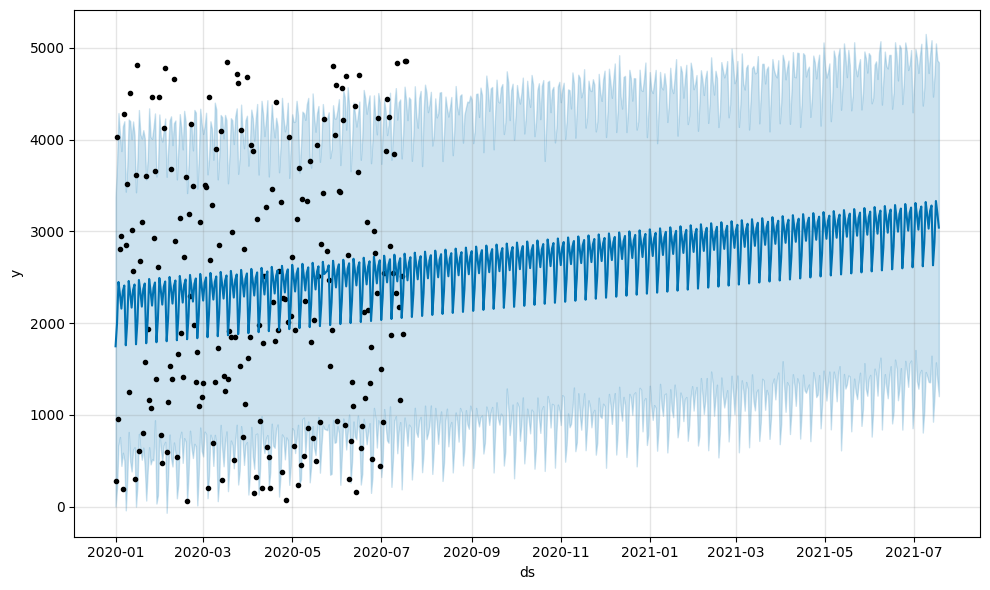

In [25]:
# plot the predicted projection
model.plot(prediction)

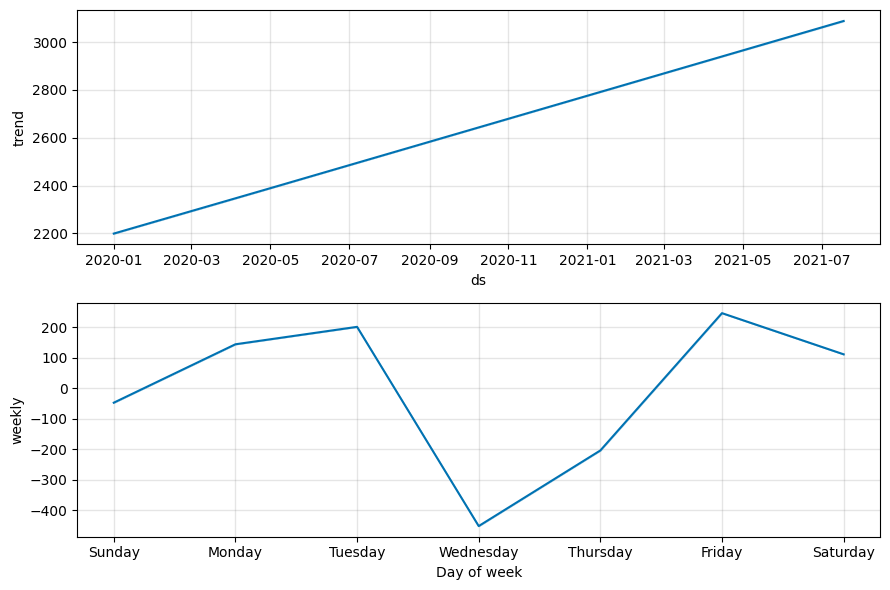

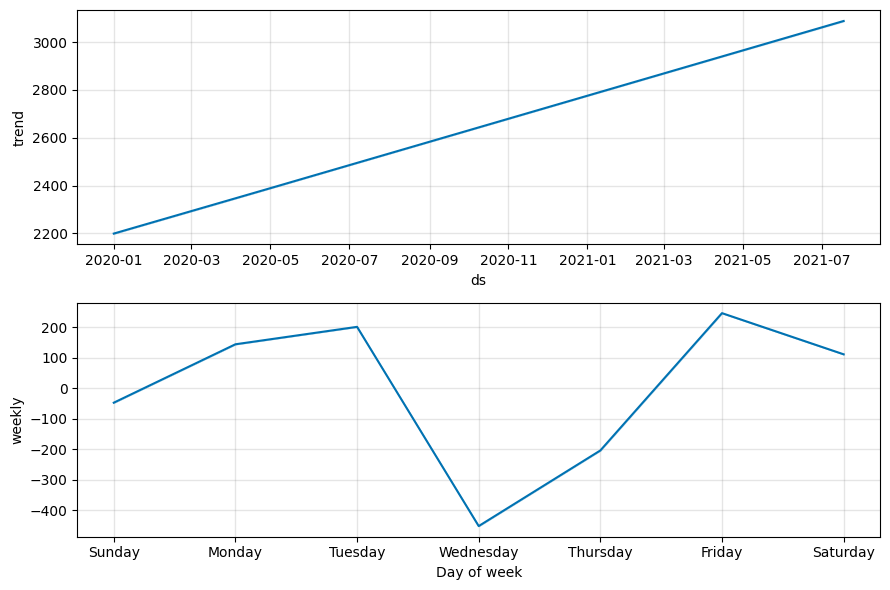

In [26]:
# Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [27]:
# Time Series Analysis

# 2020-2021

# Cross Validation

# 2020-06 to 2020-10   #Train dataset
# 2020-10 to 2020-11   #Test dataset
# 2020-11 to 2020-12   #Validation dataset

In [28]:
# Displaying First Five Rows of Dataset
df.head()

,ds,y
0,2020-01-01,285
1,2020-01-02,4030
2,2020-01-03,955
3,2020-01-04,2813
4,2020-01-05,2945


In [29]:
# Performing Cross Validation on Prophet Model
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='120 days', period='30 days', horizon = '30 days')
df_cv.head()

INFO:prophet:Making 2 forecasts with cutoffs between 2020-05-19 00:00:00 and 2020-06-18 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2020-05-20,1886.180016,225.325327,3616.771716,919,2020-05-19
1,2020-05-21,2118.224139,397.769435,3775.497684,2858,2020-05-19
2,2020-05-22,2150.537343,552.840209,3905.952247,3418,2020-05-19
3,2020-05-23,2024.632875,392.207149,3598.039509,4223,2020-05-19
4,2020-05-25,2224.325955,554.769540,3879.464868,2787,2020-05-19


In [30]:
# Calculating COVID-19 Forecast Performance Metrics
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,1.046607e+06,1023.037953,985.627916,0.529933,0.293447,0.449194,1.0
1,4 days,1.701366e+06,1304.364347,1150.289294,0.405401,0.293447,0.431794,0.8
2,5 days,1.940880e+06,1393.154783,1250.777419,0.496422,0.370820,0.475881,0.8
3,6 days,1.532565e+06,1237.968213,982.951180,0.435523,0.201892,0.390233,0.8
4,7 days,1.235807e+06,1111.668471,873.445877,1.018242,0.201892,0.486049,0.8


In [31]:
# Displaying COVID-19 Performance Metrics
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,1.046607e+06,1023.037953,985.627916,0.529933,0.293447,0.449194,1.0
1,4 days,1.701366e+06,1304.364347,1150.289294,0.405401,0.293447,0.431794,0.8
2,5 days,1.940880e+06,1393.154783,1250.777419,0.496422,0.370820,0.475881,0.8
3,6 days,1.532565e+06,1237.968213,982.951180,0.435523,0.201892,0.390233,0.8
4,7 days,1.235807e+06,1111.668471,873.445877,1.018242,0.201892,0.486049,0.8


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


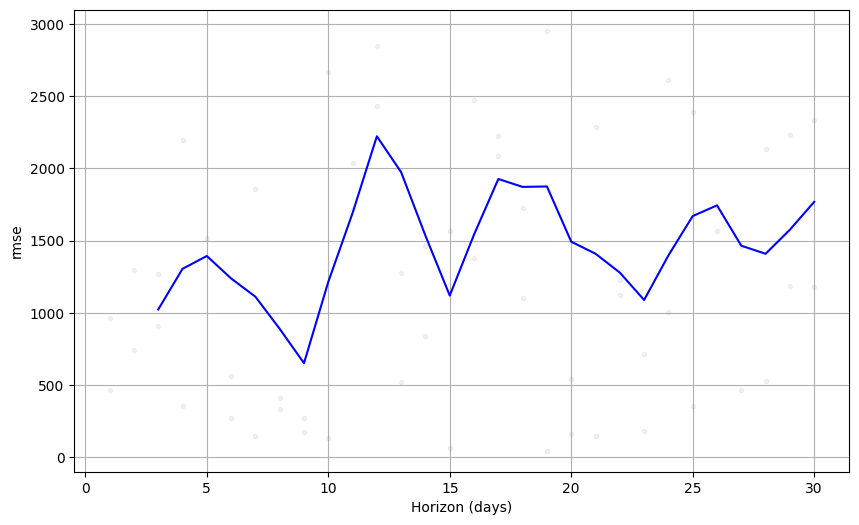

In [32]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')